# Burned area: does an earlier or later "after" date matter?

**Purpose.** Test how the choice of the "after" image affects burned-area
detection over Sentinel-2 tile T29TPG in northern Portugal.

**Dataset.** Two model burned-area maps that share the same before image
(2025-07-07) but differ in the after image (2025-09-25 vs 2025-10-15), plus the
official ICNF fire records as ground truth.

**Objectives.** (1) Measure how much area each map calls burned and how much of
that is real fire; (2) see whether a later date mostly adds seasonal browning
rather than fire; (3) map where prediction and records agree and disagree.

## 1. Setup and data

This section loads the libraries, the prediction maps, and the ground truth.
It matters because a fair comparison needs the maps, the records, and the
study-area footprint on the same grid. The reader will see what data feeds the
analysis and how the ground truth is restricted to the relevant time window.

### 1.1 Environment and plotting style

We import the libraries and set one clean, journal-ready style and colour
palette so every figure looks consistent.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import contextily as ctx

# Clean, consistent figure style
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
# Deliberate palette reused everywhere
C_FIRE  = "#c0392b"   # real fire / burned
C_SEAS  = "#e0b375"   # not fire / seasonal
C_AGREE = "#762a83"   # overlay: model and records agree
C_FALSE = "#d6604d"   # overlay: false alarm
C_MISS  = "#2c7bb6"   # overlay: missed

# Load the project config so paths are not hard-coded
for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
cfg = load_config()

### 1.2 Load the prediction maps and study area

We read the burned and observed maps for both after dates, plus the label raster
that defines the study-area footprint. Each map is 1 = burned, 0 = not, 255 = no
data; the observed map marks pixels both images could actually see.

In [2]:
BEFORE, AFTER_EARLY, AFTER_LATE = "2025-07-07", "2025-09-25", "2025-10-15"
PRED_DIR = cfg.predictions_dir
LABELS   = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01   # one 10 m pixel = 0.01 hectares

def find_raster(after_date, kind):
    """Full-tile map for an after date (ignores any sliding-window 'ov' maps)."""
    a, b = after_date.replace("-", ""), BEFORE.replace("-", "")
    hits = sorted(p for p in PRED_DIR.glob(f"T29TPG*{b}_{a}_{kind}.tif") if "_ov" not in p.name)
    if not hits:
        raise FileNotFoundError(f"No '{kind}' map for after={after_date}.")
    def cover(p):
        with rasterio.open(p) as r: return int((r.read(1) != 255).sum())
    return max(hits, key=cover)

def read(p):
    with rasterio.open(p) as r: return r.read(1)

burned = {d: read(find_raster(d, "burned"))   for d in (AFTER_EARLY, AFTER_LATE)}
obs    = {d: read(find_raster(d, "observed")) for d in (AFTER_EARLY, AFTER_LATE)}
labels = read(LABELS)
with rasterio.open(LABELS) as _r:
    GRID_T, GRID_SHAPE = _r.transform, (_r.height, _r.width)
    EXTENT = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)
# Restrict scoring to continental Portugal, no buffer (the cube has a 2 km buffer)
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                      transform=GRID_T, fill=0, dtype="uint8").astype(bool)
scored = (labels != 255) & inside_pt
print("map size:", burned[AFTER_EARLY].shape, "| footprint:", f"{scored.sum()*PIX_HA:,.0f} ha")

map size: (6304, 10980) | footprint: 547,912 ha


### 1.3 Ground truth filtered to the timeframe

We keep only ICNF fires that started on or after the before image and ended on
or before each after image, then shrink each outline by one pixel and rasterize.
This is the fairness step: a fire from spring is already burnt in the before
image, and a fire in November has not happened yet, so neither belongs here.

In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["start"] = pd.to_datetime(fires["DH_Inicio"])
fires["end"]   = pd.to_datetime(fires["DH_Fim"])

def truth_mask(after_date, erode_m=10):
    sel = fires[(fires["start"] >= pd.Timestamp(BEFORE)) & (fires["end"] <= pd.Timestamp(after_date))]
    geoms = [g for g in sel.geometry.buffer(-erode_m) if not g.is_empty]
    if not geoms:
        return np.zeros(GRID_SHAPE, dtype=bool)
    return rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE, transform=GRID_T, fill=0, dtype="uint8").astype(bool)

real = {d: truth_mask(d) for d in (AFTER_EARLY, AFTER_LATE)}
for d in (AFTER_EARLY, AFTER_LATE):
    print(f"Jul 7 -> {d}: {real[d].sum()*PIX_HA:,.0f} ha of ground-truth fire")

Jul 7 -> 2025-09-25: 10,844 ha of ground-truth fire
Jul 7 -> 2025-10-15: 11,215 ha of ground-truth fire


## 2. How much area is called burned?

This section quantifies the burned area for each date and checks how much of it
sits on real fire ground. It matters because over-calling burned area would
mislead any downstream use. The reader will learn whether the later date adds
real fire or mostly false alarms.

### 2.1 Composition of the flagged area

We break the flagged area into the part on real fire and the part that is not,
for each date, and then isolate exactly what the later date adds.

#### 2.1.1 Real fire versus not-fire split

**Objective.** For each after date, measure the total area called burned and
split it into on-real-fire and not-on-fire. **Assumption.** Only pixels both
images could see and inside the footprint are scored.

In [4]:
rows = []
for d in (AFTER_EARLY, AFTER_LATE):
    trusted = (burned[d] == 1) & (obs[d] == 1) & scored
    on  = int((trusted &  real[d]).sum())     # on real fire ground
    off = int((trusted & ~real[d]).sum())     # not on fire
    rows.append({"after_date": d, "flagged_ha": (burned[d]==1).sum()*PIX_HA,
                 "truth_ha": real[d].sum()*PIX_HA, "on_fire_ha": on*PIX_HA,
                 "not_fire_ha": off*PIX_HA, "pct_on_fire": 100*on/max(on+off,1)})
table = pd.DataFrame(rows).set_index("after_date").round(0)
table

,flagged_ha,truth_ha,on_fire_ha,not_fire_ha,pct_on_fire
after_date,,,,,
2025-09-25,23530.0,10844.0,9626.0,9862.0,49.0
2025-10-15,29211.0,11215.0,9018.0,15854.0,36.0


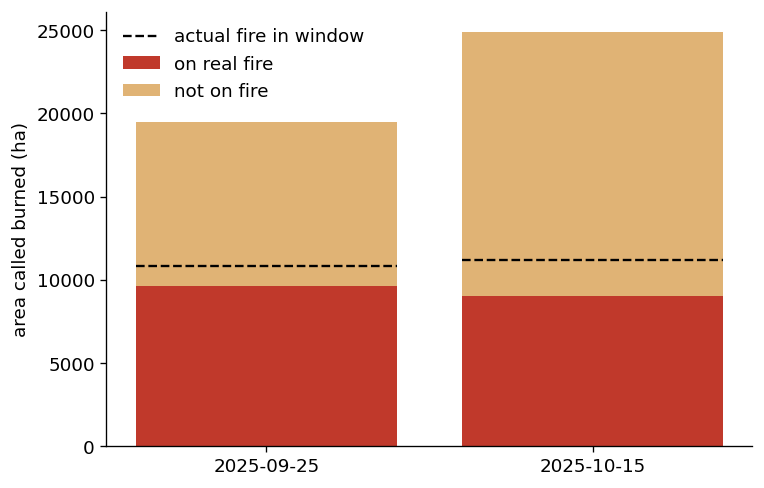

In [5]:
dates = list(table.index)
on, off, truth = table["on_fire_ha"].values, table["not_fire_ha"].values, table["truth_ha"].values
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(dates, on,  color=C_FIRE, label="on real fire")
ax.bar(dates, off, bottom=on, color=C_SEAS, label="not on fire")
for i, tt in enumerate(truth):
    ax.hlines(tt, i-0.4, i+0.4, color="black", lw=1.4, linestyles="dashed")
ax.plot([], [], "k--", lw=1.4, label="actual fire in window")
ax.set_ylabel("area called burned (ha)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.** Both bars rise well above the dashed actual-fire line,
so both maps over-call burned area. The later October date adds almost entirely
not-on-fire area, and its share on real fire is lower than September's.

#### 2.1.2 Extra area added by the later date

**Objective.** Look only at pixels the October map calls burned that September
does not, and check whether that extra area is real fire or seasonal change.
**Assumption.** Compared on pixels both dates could see.

In [6]:
both  = (obs[AFTER_EARLY]==1) & (obs[AFTER_LATE]==1) & scored
extra = (burned[AFTER_LATE]==1) & (burned[AFTER_EARLY]!=1) & both
extra_on  = int((extra &  real[AFTER_LATE]).sum())*PIX_HA
extra_off = int((extra & ~real[AFTER_LATE]).sum())*PIX_HA
print(f"extra area added by October: {extra_on+extra_off:,.0f} ha")
print(f"  on real fire : {extra_on:,.0f} ha")
print(f"  seasonal     : {extra_off:,.0f} ha ({100*extra_off/max(extra_on+extra_off,1):.0f}%)")

extra area added by October: 9,192 ha
  on real fire : 339 ha
  seasonal     : 8,853 ha (96%)


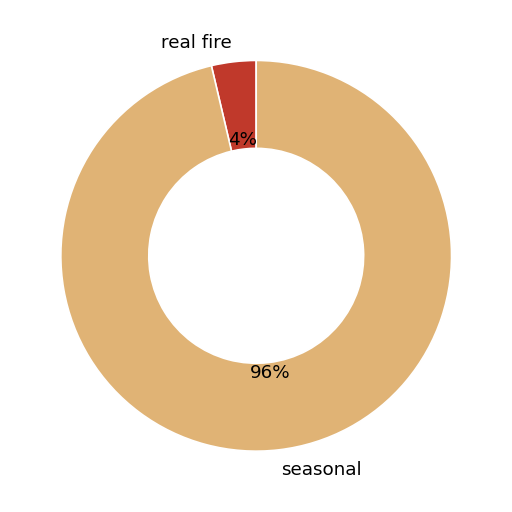

In [7]:
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.pie([extra_on, extra_off], labels=["real fire", "seasonal"],
       autopct=lambda p: f"{p:.0f}%", colors=[C_FIRE, C_SEAS],
       startangle=90, wedgeprops=dict(width=0.45, edgecolor="white"))
plt.tight_layout(); plt.show()

**Interpretation.** Almost all of the extra area the October date adds is
seasonal, not new fire. The later image is mostly capturing autumn browning and
harvest, which is the over-detection we set out to test.

## 3. Where do prediction and records agree?

This section maps agreement and disagreement on the ground. It matters because
the spatial pattern reveals whether errors are scattered (typical of seasonal
change) or compact (typical of fire). The reader will see where the model is
right, where it false-alarms, and where it misses.

### 3.1 Confusion overlay maps

We define one helper that draws a map on a light basemap with the Portugal
boundary, colouring true positives violet, false positives red, and false negatives blue.

In [8]:
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")

def confusion(d):
    m = (obs[d]==1) & scored
    p, t = (burned[d]==1) & m, real[d] & m
    return (p & t), (p & ~t), (~p & t)            # agree, false alarm, missed

def pool_or(a, k=8):
    H, W = (a.shape[0]//k)*k, (a.shape[1]//k)*k
    return a[:H, :W].reshape(H//k, k, W//k, k).max(axis=(1, 3))

def plot_overlay(d, title):
    TP, FP, FN = (pool_or(x) for x in confusion(d))
    rgba = np.zeros(TP.shape + (4,))
    for mask, col in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        rgba[mask, :3] = mcolors.to_rgb(col); rgba[mask, 3] = 0.9
    fig, ax = plt.subplots(figsize=(11, 6.5))
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3]); ax.set_aspect("equal")
    try:
        ctx.add_basemap(ax, crs="EPSG:32629", source=ctx.providers.CartoDB.Positron, attribution_size=6)
    except Exception as e:
        ax.set_facecolor("#f5f5f5"); print("basemap unavailable:", e)
    ax.imshow(rgba, extent=EXTENT, origin="upper", interpolation="nearest", zorder=3)
    PT.boundary.plot(ax=ax, color="black", linewidth=0.9, zorder=4)
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
               mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
               mpatches.Patch(color=C_MISS,  label="False negative (FN)"),
               Line2D([0],[0], color="black", lw=0.9, label="Study-area boundary")]
    ax.legend(handles=handles, loc="upper left", fontsize=9)
    plt.tight_layout(); plt.show()

#### 3.1.1 July versus September

**Objective.** Map agreement and disagreement for the earlier after date and
quantify each part. **Assumption.** Scored on observed footprint pixels.

In [9]:
TP, FP, FN = (int(x.sum()) for x in confusion(AFTER_EARLY))
print(f"September  agree {TP*PIX_HA:,.0f} ha | false alarm {FP*PIX_HA:,.0f} ha | missed {FN*PIX_HA:,.0f} ha")

September  agree 9,626 ha | false alarm 9,862 ha | missed 1,109 ha


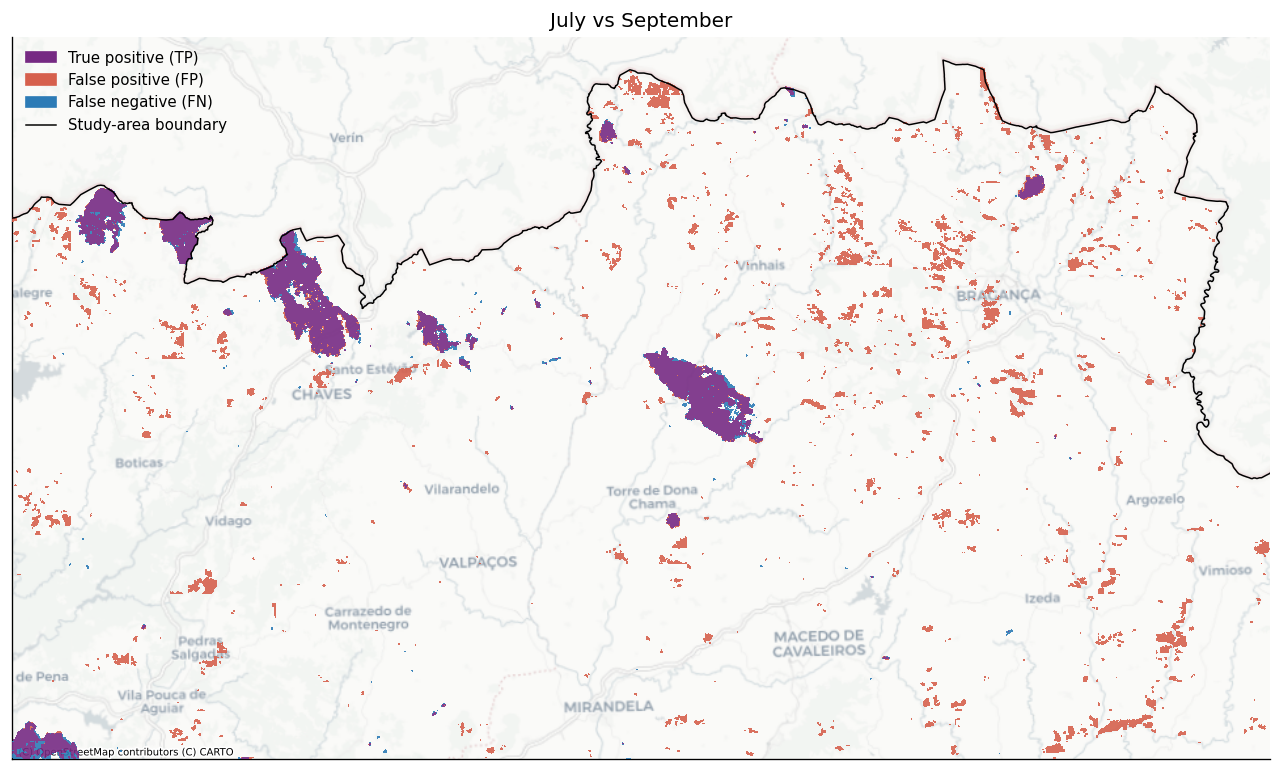

In [10]:
plot_overlay(AFTER_EARLY, "July vs September")

**Interpretation.** The violet agreement sits on the real fires. The red
false alarms are thin and scattered across farmland and hills, which looks like
seasonal change rather than burns.

#### 3.1.2 July versus October

**Objective.** Same map for the later after date, to compare the amount of red
against September. **Assumption.** Same scoring mask.

In [11]:
TP, FP, FN = (int(x.sum()) for x in confusion(AFTER_LATE))
print(f"October    agree {TP*PIX_HA:,.0f} ha | false alarm {FP*PIX_HA:,.0f} ha | missed {FN*PIX_HA:,.0f} ha")

October    agree 9,018 ha | false alarm 15,854 ha | missed 1,618 ha


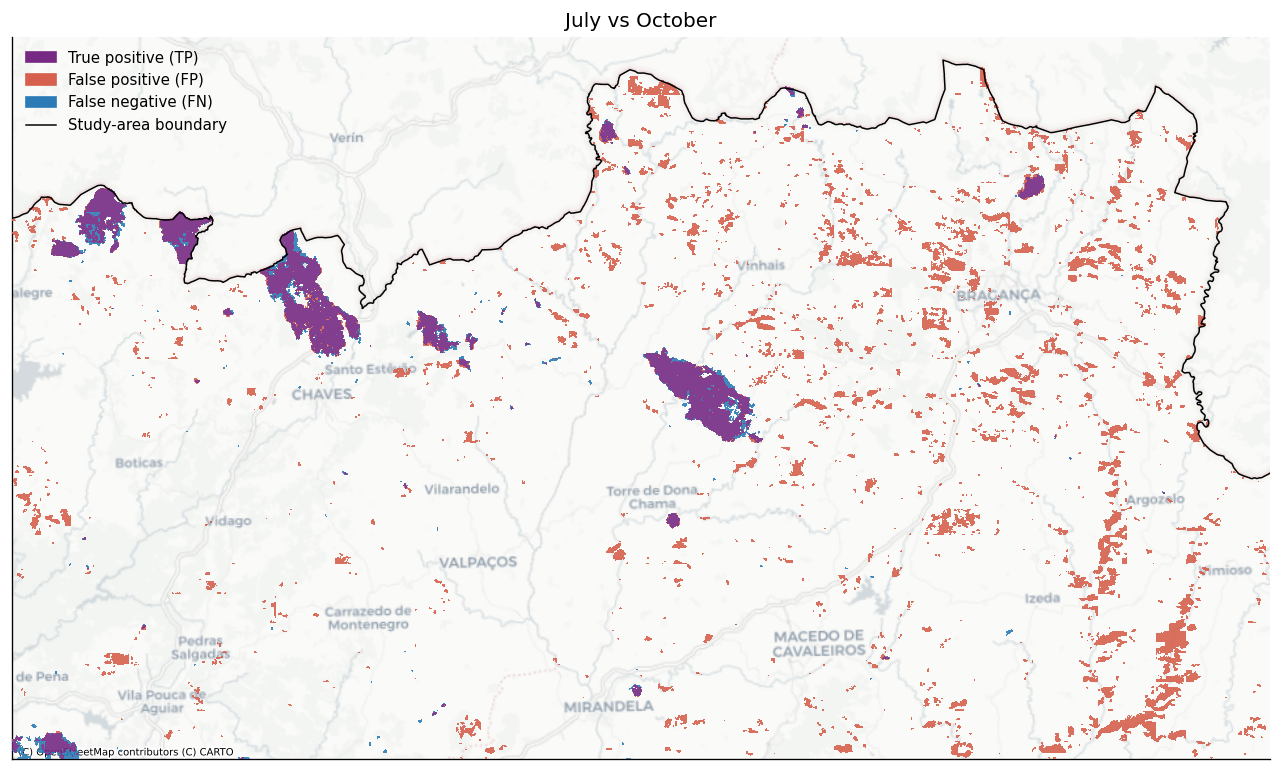

In [12]:
plot_overlay(AFTER_LATE, "July vs October")

**Interpretation.** The violet agreement is about the same as September,
but the red spreads much further. That extra red is the seasonal change the
later date introduces.

## 4. Summary

The later October date catches little more real fire than the earlier September
date, but it raises far more false alarms from autumn browning and harvest. For
a single before/after pair, the earlier clear date is the better choice. A
cleaner approach is to pair each fire with its own nearby clear dates, so the
time gap, and the seasonal change inside it, stays small.